In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

In [56]:
# =========================================================
# 1. 读取数据
# =========================================================
df = pd.read_csv("adsorption_co2.csv")

# 目标列
target_col = "adsorption"

# 删除 name，因为它只是样本ID，不适合作为普通数值特征
X = df.drop(columns=["name", target_col])
y = np.log1p(df["adsorption"])

print("数据形状:", df.shape)
print("特征数:", X.shape[1])
print("目标列:", target_col)

数据形状: (1000, 27)
特征数: 25
目标列: adsorption


In [57]:
# =========================================================
# 2. 划分数据集
# train : val : test = 60 : 20 : 20
# =========================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (600, 25) (600,)
Val  : (200, 25) (200,)
Test : (200, 25) (200,)


In [58]:
# =========================================================
# 3. 定义超参数空间
# =========================================================
param_space = {
    "n_estimators": (50, 200),       # 树的数量
    "max_depth": (3, 20),            # 树的最大深度
    "min_samples_split": (2, 10),    # 节点继续划分所需最小样本数
    "min_samples_leaf": (1, 5),      # 叶子节点最小样本数
    "max_features": (0.3, 1.0)       # 每次分裂考虑的特征比例
}

param_names = list(param_space.keys())
rng = np.random.default_rng(42)

In [59]:
# =========================================================
# 4. 随机采样超参数
# =========================================================
def sample_params(n):
    params_list = []
    for _ in range(n):
        params = {
            "n_estimators": int(rng.integers(param_space["n_estimators"][0],
                                             param_space["n_estimators"][1] + 1)),
            "max_depth": int(rng.integers(param_space["max_depth"][0],
                                          param_space["max_depth"][1] + 1)),
            "min_samples_split": int(rng.integers(param_space["min_samples_split"][0],
                                                  param_space["min_samples_split"][1] + 1)),
            "min_samples_leaf": int(rng.integers(param_space["min_samples_leaf"][0],
                                                 param_space["min_samples_leaf"][1] + 1)),
            "max_features": float(rng.uniform(param_space["max_features"][0],
                                              param_space["max_features"][1]))
        }
        params_list.append(params)
    return params_list


def params_to_vector(params):
    return np.array([params[name] for name in param_names], dtype=float)

In [60]:
# =========================================================
# 5. 定义目标函数
# metric = "r2" / "mse" / "mae"
# 注意：
#   BO通常是“最大化”
#   所以对于 mse / mae，我们返回负值，变成“越大越好”
# =========================================================
def evaluate_params(params, metric="r2"):
    model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        random_state=42,
        n_jobs=1
    )

    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)

    if metric == "r2":
        score = r2_score(y_val, pred_val)
    elif metric == "mse":
        score = -mean_squared_error(y_val, pred_val)   # 负号：让BO做最大化
    elif metric == "mae":
        score = -mean_absolute_error(y_val, pred_val)  # 负号：让BO做最大化
    else:
        raise ValueError("metric must be one of: 'r2', 'mse', 'mae'")

    return score

In [63]:
# =========================================================
# 6. EI: Expected Improvement
# =========================================================
def expected_improvement(mu, sigma, best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

In [64]:
# =========================================================
# 7. Bayesian Optimization 主循环
# =========================================================
def bayesian_optimization(metric="r2", n_init=8, n_iter=12, n_candidates=80):
    evaluated_params = []
    evaluated_scores = []

    # ---- 初始随机点 ----
    init_points = sample_params(n_init)
    for p in init_points:
        s = evaluate_params(p, metric=metric)
        evaluated_params.append(p)
        evaluated_scores.append(s)

    # ---- BO循环 ----
    for step in range(n_iter):
        X_obs = np.vstack([params_to_vector(p) for p in evaluated_params])
        y_obs = np.array(evaluated_scores)

        kernel = (
            ConstantKernel(1.0) *
            Matern(length_scale=np.ones(X_obs.shape[1]), nu=2.5) +
            WhiteKernel(1e-5)
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            random_state=42,
            n_restarts_optimizer=1
        )
        gp.fit(X_obs, y_obs)

        # 候选点池
        candidate_params = sample_params(n_candidates)
        X_cand = np.vstack([params_to_vector(p) for p in candidate_params])

        mu, sigma = gp.predict(X_cand, return_std=True)
        best_so_far = np.max(y_obs)
        ei = expected_improvement(mu, sigma, best_so_far)

        next_idx = np.argmax(ei)
        next_params = candidate_params[next_idx]
        next_score = evaluate_params(next_params, metric=metric)

        evaluated_params.append(next_params)
        evaluated_scores.append(next_score)

        print(f"Step {step+1:02d} | best objective so far = {np.max(evaluated_scores):.6f}")

    best_idx = int(np.argmax(evaluated_scores))
    best_params = evaluated_params[best_idx]
    best_score = evaluated_scores[best_idx]

    return best_params, best_score, evaluated_params, evaluated_scores


In [65]:
# =========================================================
# 8. 选择优化目标
# 可改为 "r2", "mse", "mae"
# =========================================================
metric_to_optimize = "r2"

best_params, best_score, history_params, history_scores = bayesian_optimization(
    metric=metric_to_optimize,
    n_init=8,
    n_iter=12,
    n_candidates=80
)

print("\n最优超参数:")
print(best_params)
print("BO最优目标值:", best_score)

Step 01 | best objective so far = 0.759019
Step 02 | best objective so far = 0.759019
Step 03 | best objective so far = 0.759019
Step 04 | best objective so far = 0.764396
Step 05 | best objective so far = 0.764396
Step 06 | best objective so far = 0.764396
Step 07 | best objective so far = 0.764396
Step 08 | best objective so far = 0.764771
Step 09 | best objective so far = 0.764771
Step 10 | best objective so far = 0.764771
Step 11 | best objective so far = 0.764771
Step 12 | best objective so far = 0.764771

最优超参数:
{'n_estimators': 146, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7099226330259059}
BO最优目标值: 0.7647706849493733


In [66]:
# =========================================================
# 9. 用最优参数在 train+val 上重训，再到 test 上评估
# =========================================================
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_model = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=1
)

best_model.fit(X_train_full, y_train_full)
y_pred = best_model.predict(X_test)

In [67]:
# 真实测试指标（统一都算出来）
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("\n===== Test set performance =====")
print(f"R2  = {test_r2:.6f}")
print(f"MSE = {test_mse:.6f}")
print(f"MAE = {test_mae:.6f}")


===== Test set performance =====
R2  = 0.746925
MSE = 0.062764
MAE = 0.191612


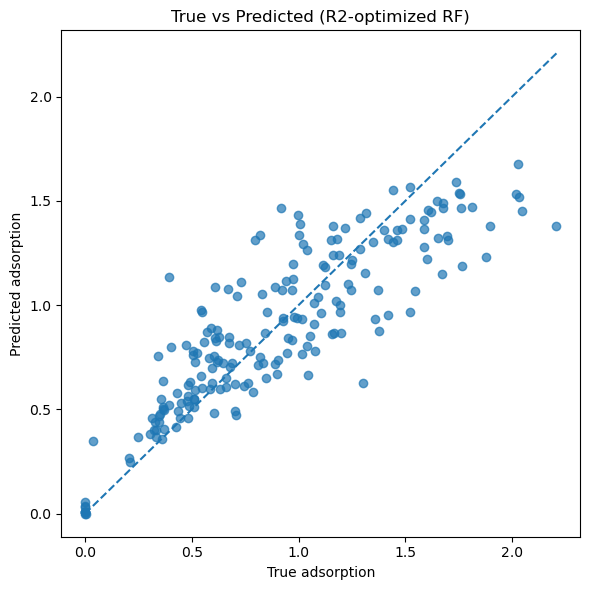

In [68]:
# =========================================================
# 10. 画图1：True value vs Predicted value
# =========================================================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

# 理想线 y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "--")

plt.xlabel("True adsorption")
plt.ylabel("Predicted adsorption")
plt.title(f"True vs Predicted ({metric_to_optimize.upper()}-optimized RF)")
plt.tight_layout()
plt.show()

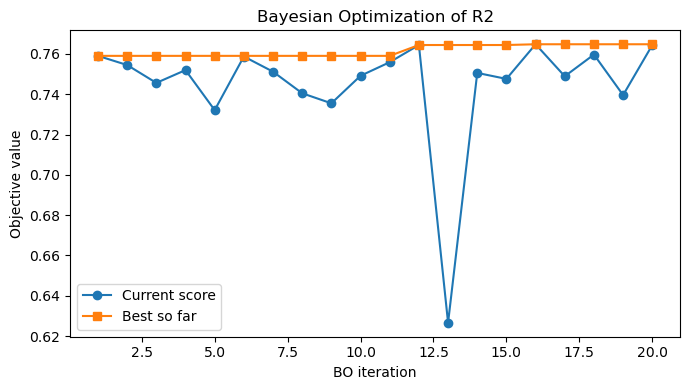

In [69]:
# =========================================================
# 11. 画图2：BO优化过程
# =========================================================
best_history = np.maximum.accumulate(history_scores)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history_scores) + 1), history_scores, marker="o", label="Current score")
plt.plot(range(1, len(best_history) + 1), best_history, marker="s", label="Best so far")
plt.xlabel("BO iteration")
plt.ylabel("Objective value")

if metric_to_optimize == "r2":
    plt.title("Bayesian Optimization of R2")
elif metric_to_optimize == "mse":
    plt.title("Bayesian Optimization of -MSE")
else:
    plt.title("Bayesian Optimization of -MAE")

plt.legend()
plt.tight_layout()
plt.show()